In [1]:
import os
import pandas as pd
import glob
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
os.chdir("C:\\Users\\willu\\OneDrive\\Dokumenter\\Microbiology PgT\\Advanced Biotech\\Computation report files")

In [3]:
os.getcwd()

'C:\\Users\\willu\\OneDrive\\Dokumenter\\Microbiology PgT\\Advanced Biotech\\Computation report files'

In [4]:
folder_path = "C:\\Users\willu\\OneDrive\\Dokumenter\Microbiology PgT\\Advanced Biotech\\Computation report files"

In [5]:
files = glob.glob(os.path.join(folder_path, "*.txt"))

In [6]:
df_list = []

for file in files:
    df = pd.read_csv(file, sep="\t")
    df["Source_File"] = os.path.basename(file)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.head())

print("Rows, Columns:", combined_df.shape)

      Gene                                  WildType.Sequence  \
0      Ah3  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   
1    Alli8  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...   
2  Anap7c1  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...   
3   App1l8  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...   
4    Avon4  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...   

                                     Mutant.Sequence  mRNA.Expression.WT.Rep1  \
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...                31.831346   
1  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...                63.891354   
2  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...                 1.629126   
3  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...                 3.619328   
4  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...                 1.398400   

   mRNA.Expression.WT.Rep2  mRNA.Expression.WT.Rep3  mRNA.Expression.Mut.Rep1  \
0                26.177081               

In [19]:
combined_df["CellViability_WT_Mean"] = combined_df[
    [
        "CellViability.WT.Rep1",
        "CellViability.WT.Rep2",
        "CellViability.WT.Rep3"
    ]
].mean(axis=1)

combined_df["CellViability_Mut_Mean"] = combined_df[
    [
        "CellViability.Mut.Rep1",
        "CellViability.Mut.Rep2",
        "CellViability.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["Viability_Difference"] = (
    combined_df["CellViability_Mut_Mean"] -
    combined_df["CellViability_WT_Mean"]
) # Negative results = reduced Viability, Positive results = increased Viability

print(combined_df[
    [
        "Gene",
        "CellViability_WT_Mean",
        "CellViability_Mut_Mean",
        "Viability_Difference"
    ]
])

ranked = combined_df.sort_values("Viability_Difference")

print(ranked[
    [
        "Gene",
        "CellViability_WT_Mean",
        "CellViability_Mut_Mean",
        "Viability_Difference"
    ]
])

pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["CellViability.WT.Rep1"],
        row["CellViability.WT.Rep2"],
        row["CellViability.WT.Rep3"]
    ]

    mut = [
        row["CellViability.Mut.Rep1"],
        row["CellViability.Mut.Rep2"],
        row["CellViability.Mut.Rep3"]
    ]

    Viability_pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["CellViability.WT.Rep1"],
        row["CellViability.WT.Rep2"],
        row["CellViability.WT.Rep3"]
    ]

    mut = [
        row["CellViability.Mut.Rep1"],
        row["CellViability.Mut.Rep2"],
        row["CellViability.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    Viability_pvals.append(p)

combined_df["Viability_p_value"] = Viability_pvals

combined_df["Significant_Viability_Shift"] = combined_df["Viability_p_value"] < 0.05

plot_df = combined_df.sort_values("Viability_Difference")

        Gene  CellViability_WT_Mean  CellViability_Mut_Mean  \
0        Ah3               0.540463                0.599650   
1      Alli8               0.136534                0.153044   
2    Anap7c1               0.522474                0.000000   
3     App1l8               0.316194                0.220864   
4      Avon4               0.642143                5.857854   
5   Cairn3a2               0.702936                0.775747   
6     Cairn6               0.842172                0.862753   
7     Clach6               0.789559                0.830611   
8    Dsgt9a1               0.304203                0.000000   
9    Ever6b6               0.232951                0.365572   
10    Everr1               0.557876                0.666745   
11      Got9               0.674150                0.696598   
12      Ist3               0.463171                0.450891   
13    Ist9a2               0.534342                5.048819   
14    Ist9a7               0.482368                0.44

In [8]:
combined_df["mRNAExpression_WT_Mean"] = combined_df[
    [
        "mRNA.Expression.WT.Rep1",
        "mRNA.Expression.WT.Rep2",
        "mRNA.Expression.WT.Rep3"
    ]
].mean(axis=1)

combined_df["mRNAExpression_Mut_Mean"] = combined_df[
    [
        "mRNA.Expression.Mut.Rep1",
        "mRNA.Expression.Mut.Rep2",
        "mRNA.Expression.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["mRNA_Expression_Difference"] = (
    combined_df["mRNAExpression_Mut_Mean"] -
    combined_df["mRNAExpression_WT_Mean"]
)

print(combined_df[
    [
        "Gene",
        "mRNAExpression_WT_Mean",
        "mRNAExpression_Mut_Mean",
        "mRNA_Expression_Difference"
    ]
])

ranked = combined_df.sort_values("mRNA_Expression_Difference")

print(ranked[
    [
        "Gene",
        "mRNAExpression_WT_Mean",
        "mRNAExpression_Mut_Mean",
        "mRNA_Expression_Difference"
    ]
])

mRNA_pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["mRNA.Expression.WT.Rep1"],
        row["mRNA.Expression.WT.Rep2"],
        row["mRNA.Expression.WT.Rep3"]
    ]

    mut = [
        row["mRNA.Expression.Mut.Rep1"],
        row["mRNA.Expression.Mut.Rep2"],
        row["mRNA.Expression.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    mRNA_pvals.append(p)

combined_df["mRNA_p_value"] = mRNA_pvals

combined_df["Significant_mRNA_Expression_Shift"] = combined_df["mRNA_p_value"] < 0.05

plot_df = combined_df.sort_values("mRNA_Expression_Difference")

        Gene  mRNAExpression_WT_Mean  mRNAExpression_Mut_Mean  \
0        Ah3            2.491459e+01             2.578757e+01   
1      Alli8            2.765717e+01             2.692833e+01   
2    Anap7c1            9.957710e+00            -3.957048e+01   
3     App1l8            4.057949e+00             3.632353e+00   
4      Avon4            2.512790e+00             3.958356e+00   
5   Cairn3a2            2.536683e+01             2.574975e+01   
6     Cairn6            1.757151e+03             1.757414e+03   
7     Clach6            8.647071e+00             7.966945e+00   
8    Dsgt9a1            3.790932e+01             4.167821e+01   
9    Ever6b6            1.059454e+06             1.059454e+06   
10    Everr1            1.953909e+02             1.954727e+02   
11      Got9            6.000992e+01             6.020909e+01   
12      Ist3            8.101198e+00             8.773715e+00   
13    Ist9a2            5.010363e+03             2.242457e-05   
14    Ist9a7            1

In [15]:
combined_df["ProteinExpression_WT_Mean"] = combined_df[
    [
        "Protein.Expression.WT.Rep1",
        "Protein.Expression.WT.Rep2",
        "Protein.Expression.WT.Rep3"
    ]
].mean(axis=1)

combined_df["ProteinExpression_Mut_Mean"] = combined_df[
    [
        "Protein.Expression.Mut.Rep1",
        "Protein.Expression.Mut.Rep2",
        "Protein.Expression.Mut.Rep3"
    ]
].mean(axis=1)

combined_df["Protein_Expression_Difference"] = (
    combined_df["ProteinExpression_Mut_Mean"] -
    combined_df["ProteinExpression_WT_Mean"]
)

print(combined_df[
    [
        "Gene",
        "ProteinExpression_WT_Mean",
        "ProteinExpression_Mut_Mean",
        "Protein_Expression_Difference"
    ]
])

ranked = combined_df.sort_values("Protein_Expression_Difference")

print(ranked[
    [
        "Gene",
        "ProteinExpression_WT_Mean",
        "ProteinExpression_Mut_Mean",
        "Protein_Expression_Difference"
    ]
])
Protein_pvals = []

for i, row in combined_df.iterrows():

    wt = [
        row["Protein.Expression.WT.Rep1"],
        row["Protein.Expression.WT.Rep2"],
        row["Protein.Expression.WT.Rep3"]
    ]

    mut = [
        row["Protein.Expression.Mut.Rep1"],
        row["Protein.Expression.Mut.Rep2"],
        row["Protein.Expression.Mut.Rep3"]
    ]

    stat, p = ttest_ind(wt, mut)
    Protein_pvals.append(p)

combined_df["Protein_p_value"] = Protein_pvals

combined_df["Significant_Protein_Expression_Shift"] = combined_df["Protein_p_value"] < 0.05

plot_df = combined_df.sort_values("Protein_Expression_Difference")

        Gene  ProteinExpression_WT_Mean  ProteinExpression_Mut_Mean  \
0        Ah3               25176.666667                25184.000000   
1      Alli8               20556.333333                20565.333333   
2    Anap7c1               21147.666667                10071.333333   
3     App1l8               26965.333333                26974.000000   
4      Avon4               35318.333333                55350.000000   
5   Cairn3a2               28437.666667                28449.666667   
6     Cairn6               36524.333333                36537.666667   
7     Clach6               20376.000000                20384.666667   
8    Dsgt9a1               19030.333333                36188.666667   
9    Ever6b6               19785.666667                19795.000000   
10    Everr1               12922.000000                12928.666667   
11      Got9               32568.333333                32580.333333   
12      Ist3               22426.333333                22439.666667   
13    

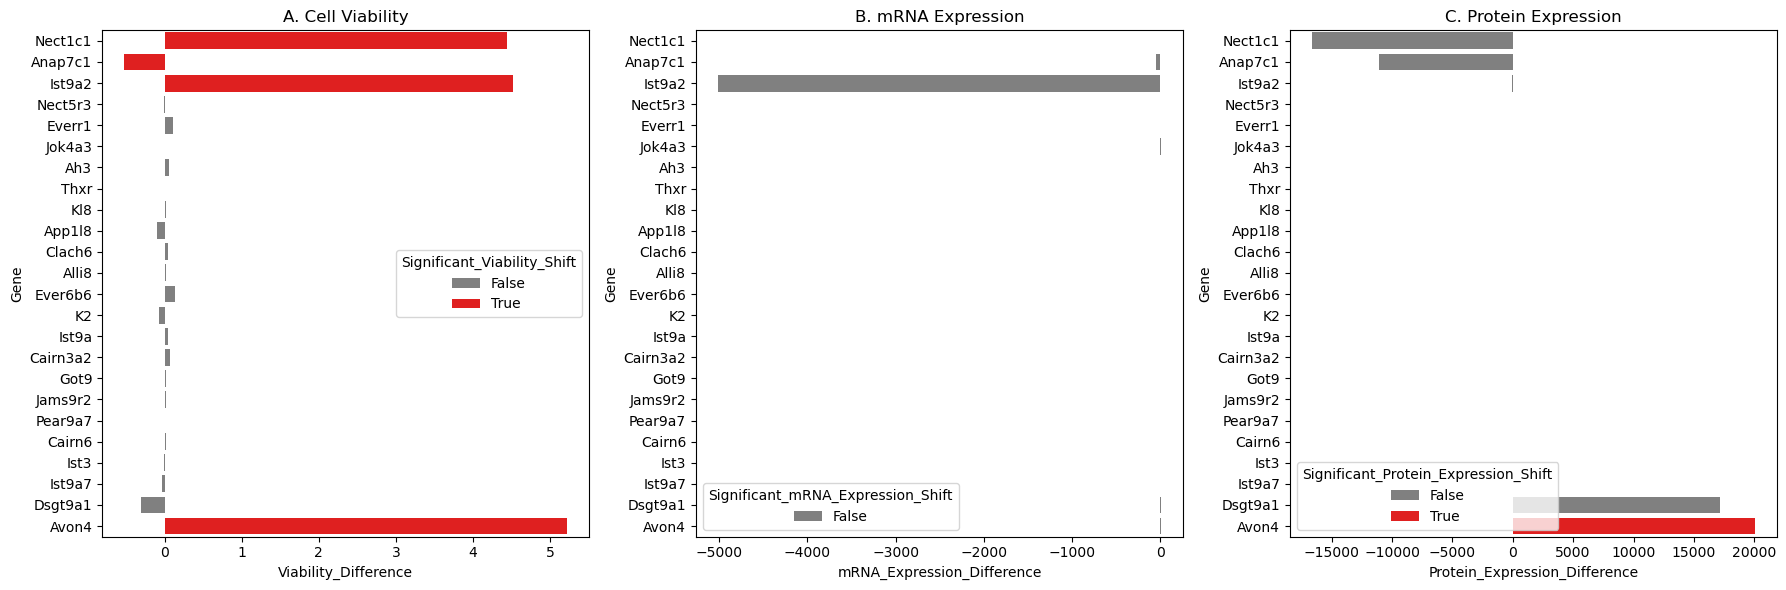

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.barplot(
    data=plot_df,
    x="Viability_Difference",
    y="Gene",
    hue="Significant_Viability_Shift",
    dodge=False,
    palette={True:"red", False: "grey"},
    ax=axes[0]
)
axes[0].set_title("A. Cell Viability")

sns.barplot(
    data=plot_df,
    x="mRNA_Expression_Difference",
    y="Gene",
    hue="Significant_mRNA_Expression_Shift",
    dodge=False,
    palette={True:"red", False: "grey"},
    ax=axes[1]
)
axes[1].set_title("B. mRNA Expression")

sns.barplot(
    data=plot_df,
    x="Protein_Expression_Difference",
    y="Gene",
    hue="Significant_Protein_Expression_Shift",
    dodge=False,
    palette={True:"red", False: "grey"},
    ax=axes[2]
)
axes[2].set_title("C. Protein Expression")

plt.tight_layout()
plt.show()

In [11]:
print(plot_df[["Gene", "Viability_p_value", "Significant_Viability_Shift"]])

        Gene  Viability_p_value  Significant_Viability_Shift
20   Nect1c1           0.005540                         True
2    Anap7c1           0.021266                         True
13    Ist9a2           0.015697                         True
21   Nect5r3           0.981678                        False
10    Everr1           0.785279                        False
17    Jok4a3           0.984115                        False
0        Ah3           0.774878                        False
23      Thxr           0.986864                        False
19       Kl8           0.954107                        False
3     App1l8           0.629868                        False
7     Clach6           0.816986                        False
1      Alli8           0.834365                        False
9    Ever6b6           0.599827                        False
18        K2           0.731119                        False
15     Ist9a           0.857099                        False
5   Cairn3a2           0

In [12]:
print(plot_df[["Gene", "mRNA_p_value", "Significant_mRNA_Expression_Shift"]])

        Gene  mRNA_p_value  Significant_mRNA_Expression_Shift
20   Nect1c1      0.938229                              False
2    Anap7c1      0.234441                              False
13    Ist9a2      0.372523                              False
21   Nect5r3      0.996986                              False
10    Everr1      0.999775                              False
17    Jok4a3      0.135227                              False
0        Ah3      0.892630                              False
23      Thxr      0.995636                              False
19       Kl8      0.983432                              False
3     App1l8      0.871575                              False
7     Clach6      0.931855                              False
1      Alli8      0.978741                              False
9    Ever6b6      1.000000                              False
18        K2      0.998012                              False
15     Ist9a      0.992863                              False
5   Cair

In [13]:
print(plot_df[["Gene", "Protein_p_value", "Significant_Protein_Expression_Shift"]])

        Gene  Protein_p_value  Significant_Protein_Expression_Shift
20   Nect1c1         0.348272                                 False
2    Anap7c1         0.364009                                 False
13    Ist9a2         0.330256                                 False
21   Nect5r3         0.999636                                 False
10    Everr1         0.999356                                 False
17    Jok4a3         0.998879                                 False
0        Ah3         0.999473                                 False
23      Thxr         0.998402                                 False
19       Kl8         0.999507                                 False
3     App1l8         0.999624                                 False
7     Clach6         0.999679                                 False
1      Alli8         0.999577                                 False
9    Ever6b6         0.999657                                 False
18        K2         0.999418                   

In [14]:
# Genes to analyse further: Nect1c1, Anap7c1, Ist9a2, Avon4 and Dsgt9a1